<a href="https://colab.research.google.com/github/sandraremedios/Classificacao-alimentos-IA/blob/main/classificacao_alimentos_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Reviews.csv to Reviews.csv


In [4]:
df = pd.read_csv("Reviews.csv")

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [6]:
df = df[["Text","Score"]]

df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [7]:
df = df[df["Score"] != 3]

df["sentimento"] = df["Score"].apply(
    lambda x: "Positivo" if x >= 4 else "Negativo"
)

df.head()

,Text,Score,sentimento
0,I have bought several of the Vitality canned d...,5,Positivo
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negativo
2,This is a confection that has been around a fe...,4,Positivo
3,If you are looking for the secret ingredient i...,2,Negativo
4,Great taffy at a great price. There was a wid...,5,Positivo


In [8]:
df.rename(columns={"Text":"comentario"}, inplace=True)

df = df[["comentario","sentimento"]]

df.head()

,comentario,sentimento
0,I have bought several of the Vitality canned d...,Positivo
1,Product arrived labeled as Jumbo Salted Peanut...,Negativo
2,This is a confection that has been around a fe...,Positivo
3,If you are looking for the secret ingredient i...,Negativo
4,Great taffy at a great price. There was a wid...,Positivo


In [9]:
print(df["sentimento"].value_counts())

sentimento
Positivo    443777
Negativo     82037
Name: count, dtype: int64


In [11]:
X = df["comentario"]

y = df["sentimento"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
modelo = Pipeline([

    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000
    )),

    ("naive", MultinomialNB())

])

In [13]:
modelo.fit(X_train, y_train)

print("Treinamento concluído!")

Treinamento concluído!


In [14]:
predicoes = modelo.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, predicoes)

print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.8856


In [16]:
print(classification_report(y_test, predicoes))

              precision    recall  f1-score   support

    Negativo       0.89      0.30      0.45     16407
    Positivo       0.89      0.99      0.94     88756

    accuracy                           0.89    105163
   macro avg       0.89      0.65      0.69    105163
weighted avg       0.89      0.89      0.86    105163



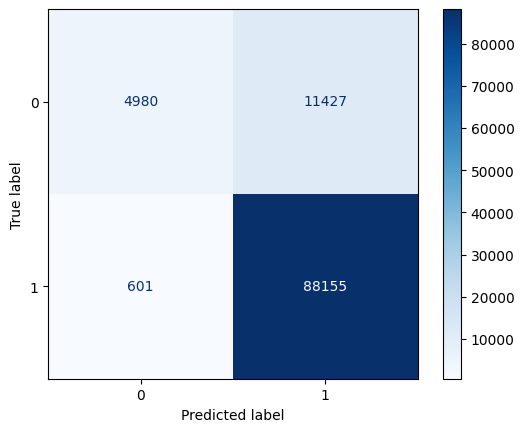

In [17]:
matriz = confusion_matrix(y_test, predicoes)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

disp.plot(cmap="Blues")

plt.show()

In [18]:
comentarios = [

"This product is amazing!",

"I loved it!",

"Terrible quality.",

"Very bad experience.",

"Excellent!",

"I will buy again."

]

for comentario in comentarios:

    resultado = modelo.predict([comentario])[0]

    print("--------------------------------")
    print(comentario)
    print("Sentimento:", resultado)

--------------------------------
This product is amazing!
Sentimento: Positivo
--------------------------------
I loved it!
Sentimento: Positivo
--------------------------------
Terrible quality.
Sentimento: Negativo
--------------------------------
Very bad experience.
Sentimento: Positivo
--------------------------------
Excellent!
Sentimento: Positivo
--------------------------------
I will buy again.
Sentimento: Positivo


In [19]:
texto = input("Digite um comentário em inglês: ")

modelo.predict([texto])[0]

Digite um comentário em inglês: this rice is disgusting


np.str_('Negativo')

In [20]:
joblib.dump(modelo, "modelo_sentimentos.pkl")

['modelo_sentimentos.pkl']

In [21]:
from google.colab import files

files.download("modelo_sentimentos.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
accuracy_score(y_test, predicoes)

print(classification_report(y_test, predicoes))

              precision    recall  f1-score   support

    Negativo       0.89      0.30      0.45     16407
    Positivo       0.89      0.99      0.94     88756

    accuracy                           0.89    105163
   macro avg       0.89      0.65      0.69    105163
weighted avg       0.89      0.89      0.86    105163

